<a href="https://colab.research.google.com/github/Aparna0905/Gen_Ai_Monday_Lab/blob/main/Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed


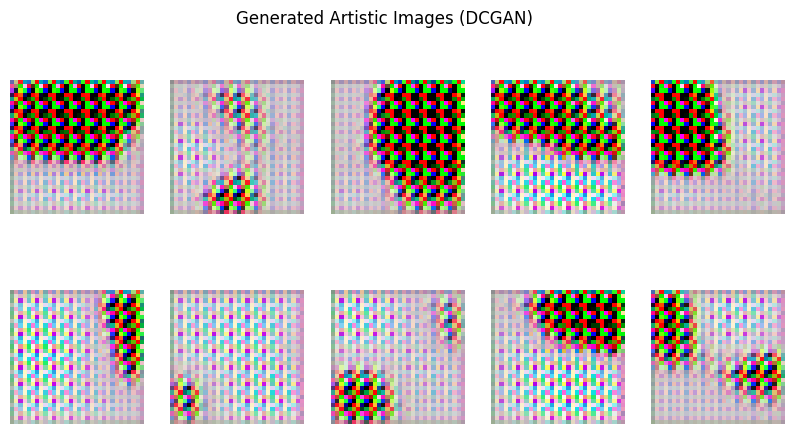

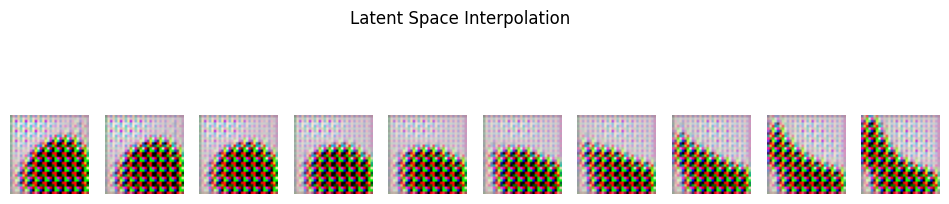

In [1]:


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

# -----------------------------
# 1. DATA PREPARATION
# -----------------------------

(x_train, _), (_, _) = cifar10.load_data()

x_train = (x_train.astype('float32') - 127.5) / 127.5
BUFFER_SIZE = 60000
BATCH_SIZE = 256

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

latent_dim = 100

# -----------------------------
# 2. GENERATOR
# -----------------------------

def build_generator():

    model = tf.keras.Sequential()

    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8,8,256)))

    model.add(layers.Conv2DTranspose(128,4,strides=2,padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64,4,strides=2,padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3,3,strides=1,padding='same',
                                     activation='tanh'))

    return model


# -----------------------------
# 3. DISCRIMINATOR
# -----------------------------

def build_discriminator():

    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64,4,strides=2,padding='same',
                            input_shape=[32,32,3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128,4,strides=2,padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


generator = build_generator()
discriminator = build_discriminator()

# -----------------------------
# LOSS FUNCTIONS
# -----------------------------

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    return real_loss + fake_loss


generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# -----------------------------
# TRAINING STEP
# -----------------------------

@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss,
                                               generator.trainable_variables)

    gradients_of_discriminator = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator,
                                            generator.trainable_variables))

    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,
                                                discriminator.trainable_variables))


# -----------------------------
# TRAIN GAN (FAST TRAINING)
# -----------------------------

EPOCHS = 3

for epoch in range(EPOCHS):

    for image_batch in dataset:

        train_step(image_batch)

    print("Epoch", epoch+1, "completed")


# -----------------------------
# GENERATE ARTISTIC SAMPLES
# -----------------------------

noise = tf.random.normal([10, latent_dim])

generated_images = generator(noise)

generated_images = (generated_images + 1) / 2

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")

plt.suptitle("Generated Artistic Images (DCGAN)")
plt.show()


# -----------------------------
# LATENT SPACE INTERPOLATION
# -----------------------------

z1 = tf.random.normal([1, latent_dim])
z2 = tf.random.normal([1, latent_dim])

alphas = np.linspace(0,1,10)

images = []

for a in alphas:

    z = (1-a)*z1 + a*z2
    img = generator(z)

    images.append(img[0])

images = (np.array(images)+1)/2

plt.figure(figsize=(12,3))

for i,img in enumerate(images):

    plt.subplot(1,10,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Latent Space Interpolation")
plt.show()



